# Orders - Phases 4 (test) + 5 + 6 (PLAN.md §8)

The test week has not been touched anywhere else in the pipeline. This notebook is where it is
finally opened - once - and carried straight through to an order:

| § | What it does | Phase |
|---|---|---|
| 1 | forecast the test week from the already-fit checkpoint - no retraining | 4 |
| 2 | calibrate the bands - split-conformal offsets fit on the calibration period | 5 |
| 3 | load the corrected test forecast (the 5-quantile grid, if both bands were run) | 5 |
| 4 | the newsvendor rule - critical fractile -> order quantity, worked example | 6 |
| 5 | the naive competitor - "order what sold same day last week" | 6 |
| 6 | headline run - one representative cost ratio, per-product-day results | 6 |
| 7 | the cost-ratio sweep - the business-KPI proof | 6 |
| 8 | write-up - definition of done | 6 |

All logic lives in `src/forecast.py`, `src/conformal.py` and `src/orders.py`; this notebook is the
control surface + the figures, same split as `01_data_and_recovery.ipynb` / `02_forecasting.ipynb`.

**Ground rules this notebook must respect (PLAN.md §4):** the test week is opened once, at the
final evaluation (rule 5) - §1 below is that evaluation, so re-run it only when you mean to score
or order against the test week, not while iterating on anything upstream; simulate against
`recovered_demand`, not `sale_amount` (rule 2) - a store orders every day, and the censored days
are exactly where the fill-in layer pays off; costs are swept, never fixed at one lucky ratio
(rule 4); §1 reads a checkpoint `02_forecasting.ipynb` already fit, it never retrains one (rule 7).

## 0. Imports

In [1]:
import sys
sys.path.insert(0, "..")   # notebooks/ is one level down, so the repo root has to go on the path

import json

import pandas as pd

from src.utils import config, data_io, plots
from src import baselines, recovery, splits


def saved(path, flag):
    """Read a saved table, or name the flag that regenerates it."""
    if not path.exists():
        raise FileNotFoundError(f"{path.name} not found - set {flag} = True and re-run that cell")
    return pd.read_csv(path, index_col=0)

In [2]:
import pandas as pd

from src.utils import config, plots
from src import conformal, forecast, orders

print("repo root:", config.ROOT)
print("outputs  :", config.OUTPUTS_DIR)

repo root: /Users/Kavitha/Documents/retail-demand-forecasting-main
outputs  : /Users/Kavitha/Documents/retail-demand-forecasting-main/outputs


## 1. Forecast the test week (Phase 4 - opened once)

`01_data_and_recovery.ipynb` and `02_forecasting.ipynb` never touch the test week - hyperparameter
search, training and early stopping all happen on train/validation/calibration only. This cell
reloads the checkpoint that produced (`outputs/models/tft_best_recovered.ckpt`) and forecasts the
test week from it via `forecast.forecast_test` - **no retraining**, so nothing about the test week
can leak into the model that was fit. This is the one-time evaluation ground rule 5 refers to.

`forecast.build_master_frame()` is the same daily frame `02_forecasting.ipynb` builds by hand -
recovered demand, raw sales and the stockout flag, across every split including the test week.

Set `RUN_TEST_FORECAST = False` after the first run to just reload the saved
`forecast_test_recovered.parquet` instead of forecasting again.

In [3]:
RUN_TEST_FORECAST = True   # False = load the saved test forecast from outputs/

daily = forecast.build_master_frame()

if RUN_TEST_FORECAST:
    test_recovered = forecast.forecast_test(daily, tag="recovered")
else:
    test_recovered = pd.read_parquet(config.forecast_parquet("test", "recovered"))

print(f"{len(test_recovered):,} test product-days forecast | "
      f"{test_recovered['dt'].min().date()} .. {test_recovered['dt'].max().date()}")
test_recovered.head(3)

loading daily subset from /Users/Kavitha/Documents/retail-demand-forecasting-main/data/processed/daily_train.parquet + /Users/Kavitha/Documents/retail-demand-forecasting-main/data/processed/daily_eval.parquet
loading recovered subset from /Users/Kavitha/Documents/retail-demand-forecasting-main/data/processed/daily_train_recovered.parquet + /Users/Kavitha/Documents/retail-demand-forecasting-main/data/processed/daily_eval_recovered.parquet


/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'logging_metrics' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['logging_metrics'])`.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
/opt/anaconda3/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, un

39,207 test product-days forecast | 2024-06-26 .. 2024-07-02


,store_id,product_id,time_idx,dt,sale_amount,stock_hour6_22_cnt,recovered_demand,is_censored,q025,q10,q50,q80,q90,q975
0,10,116,90,2024-06-26,0.4,4,0.502696,1,0.099609,0.213092,0.445190,0.621769,0.700643,0.868467
1,10,116,91,2024-06-27,0.3,0,0.300000,0,0.097348,0.208997,0.437407,0.611122,0.687637,0.852464
2,10,116,92,2024-06-28,0.3,12,0.691420,1,0.120401,0.240431,0.482911,0.664182,0.748286,0.918194


## 2. Calibrate the bands (Phase 5 - conformal)

The raw 80% band (q10/q90) is overconfident - it does not cover the nominal 80% of actuals.
`src/conformal.py` fixes this without retraining: split-CQR (Romano 2019) fits one offset per
band on the CALIBRATION period (never trained on, never the test week), then widens the test
forecast's q10/q90 and q025/q975 by it.

Two `conformal.run()` calls because two BANDS are corrected, not because there are two models -
both read the SAME `forecast_test_recovered.parquet` §1 just wrote, one correcting the 80% band
(`tag="wide80"`) and one the 95% band (`tag="wide95"`). Together they give `orders.py` a 5-point
corrected quantile grid (`q025_c/q10_c/q50/q90_c/q975_c`) instead of just 3 points.

Set `RUN_CONFORMAL = False` after the first run to just reload the saved corrected-test parquets.

In [4]:
RUN_CONFORMAL = True   # False = load the saved conformal outputs from outputs/

if RUN_CONFORMAL:
    conformal.run(nominal=0.80, lower="q10", upper="q90", tag="wide80", forecast_tag="recovered")
    conformal.run(nominal=0.95, lower="q025", upper="q975", tag="wide95", forecast_tag="recovered")
else:
    print("RUN_CONFORMAL=False - reusing outputs/forecast_test_conformal_wide80.parquet + "
          "_wide95.parquet from a previous run")

loading daily subset from /Users/Kavitha/Documents/retail-demand-forecasting-main/data/processed/daily_train.parquet + /Users/Kavitha/Documents/retail-demand-forecasting-main/data/processed/daily_eval.parquet
loading recovered subset from /Users/Kavitha/Documents/retail-demand-forecasting-main/data/processed/daily_train_recovered.parquet + /Users/Kavitha/Documents/retail-demand-forecasting-main/data/processed/daily_eval_recovered.parquet

CQR 80% [q10/q90]  |  calib=calibration (45,028 observed rows)  |  offset Q = 0.0775
  [validation] scored on 47,994 of 78,414 rows  uncorrected 0.738 (w 0.944)  ->  corrected 0.826 (w 1.096)  Kupiec p=0.0 ok=False
  [test      ] scored on 23,402 of 39,207 rows  uncorrected 0.678 (w 0.891)  ->  corrected 0.760 (w 1.043)  Kupiec p=0.0 ok=False
  saved test intervals for ALL 39,207 product-days (Phase 6 orders on every day, not just the observed ones)
loading daily subset from /Users/Kavitha/Documents/retail-demand-forecasting-main/data/processed/daily_

## 3. Load the corrected test forecast

`orders.load_test_forecast(wide=True)` merges the two 95%-band-model conformal runs
(`forecast_test_conformal_wide80.parquet` + `..._wide95.parquet`) into one corrected 5-point
quantile grid - `q025_c / q10_c / q50 / q90_c / q975_c` - so the Monte Carlo demand draws have
real tails instead of being built from just q10/q50/q90. Falls back to the canonical 3-point
80%-band file if the wide run isn't there.

Every row is a test product-day, censored or not (ground rule 2/3 nuance carried over from
Phase 5): `observed` marks the non-stockout days, but the order simulation runs on **all** of
them - `recovered_demand` is the simulation target throughout.

In [5]:
test_df, qcols = orders.load_test_forecast(wide=True)
print(f"{len(test_df):,} test product-days | quantile grid: {qcols}")
print(f"censored (not directly observed): {(~test_df['observed']).mean():.1%}")
test_df.head(3)

39,207 test product-days | quantile grid: {0.025: 'q025_c', 0.1: 'q10_c', 0.5: 'q50', 0.9: 'q90_c', 0.975: 'q975_c'}
censored (not directly observed): 40.3%


,store_id,product_id,dt,q50,q10_c,q90_c,recovered_demand,sale_amount,observed,stock_hour6_22_cnt,q025_c,q975_c
0,10,116,2024-06-26,0.445190,0.135557,0.778178,0.502696,0.4,False,4,0.0,1.038839
1,10,116,2024-06-27,0.437407,0.131462,0.765172,0.300000,0.3,True,0,0.0,1.022836
2,10,116,2024-06-28,0.482911,0.162896,0.825821,0.691420,0.3,False,12,0.0,1.088566


## 4. The newsvendor rule

```
q* = c_u / (c_u + c_o)
```

A missed sale costs `c_u` (under-order); a wasted unit costs `c_o` (over-order). The optimal
order is simply the **q\*-th quantile of the demand distribution** - which is exactly why
Phases 4-5 exist: the order is only as trustworthy as the quantile it reads, so the quantile had
to be calibrated first. `order_quantity` reads that quantile off each row's corrected forecast by
linear interpolation between the saved quantile points (`orders._tau_breakpoints`).

In [6]:
for c_u, c_o in [(1, 4), (1, 1), (4, 1)]:
    q_star = orders.critical_fractile(c_u, c_o)
    print(f"c_u={c_u}, c_o={c_o}  ->  q* = {q_star:.3f}  "
          f"({'waste-averse' if q_star < 0.5 else 'stockout-averse' if q_star > 0.5 else 'balanced'})")

# worked example: one series, one row
example = test_df.iloc[[0]]
for q_star in (0.2, 0.5, 0.8, 0.95):
    qty = orders.order_quantity(example, q_star, qcols)[0]
    print(f"  q*={q_star:.2f}  ->  order {qty:.2f} units "
          f"(recovered_demand that day was {example['recovered_demand'].iloc[0]:.2f})")

c_u=1, c_o=4  ->  q* = 0.200  (waste-averse)
c_u=1, c_o=1  ->  q* = 0.500  (balanced)
c_u=4, c_o=1  ->  q* = 0.800  (stockout-averse)
  q*=0.20  ->  order 0.21 units (recovered_demand that day was 0.50)
  q*=0.50  ->  order 0.45 units (recovered_demand that day was 0.50)
  q*=0.80  ->  order 0.69 units (recovered_demand that day was 0.50)
  q*=0.95  ->  order 0.95 units (recovered_demand that day was 0.50)


## 5. The naive competitor

The status-quo rule (§2b): *order what sold same day last week*, off the RAW sales history a
store actually has (no fill-in, no calibration - that is the point of the comparison). Every
test date's -7 days lands inside the frozen calibration window, so this is an exact lookup, not
an approximation.

In [7]:
naive_order = orders.naive_orders(test_df)
print(f"naive order: mean {naive_order.mean():.3f}, median {pd.Series(naive_order).median():.3f} "
      f"sale_amount/day, normalized (recovered_demand mean: {test_df['recovered_demand'].mean():.3f})")

naive order: mean 1.196, median 0.800 sale_amount/day, normalized (recovered_demand mean: 1.351)


## 6. Headline run

One representative cost ratio - `c_u/c_o = 4` (missing a sale hurts 4x more than wasting a
unit), i.e. `q* = 0.8`, matching the canonical 80% band's own service level. Draws demand once
(`n_draws=5,000` - large enough to be stable at ~39K rows, small enough to fit in RAM
without swapping; 10,000 measured at ~52 min wall-clock vs. ~5 min of actual CPU time on
this machine, all of it memory-thrashing) and reuses the SAME draws for every policy
compared below (common random
numbers - a fair, low-variance ours-vs-naive comparison). This is also what `orders.run()` saves
to `outputs/order_simulation.csv` - the Order tab's input.

In [8]:
result = orders.run(c_u=orders.HEADLINE_RATIO, c_o=1.0, wide=True, n_draws=5_000,
                    random_state=config.RANDOM_STATE, save=True, verbose=True)
per_day, sweep, kpi = result["per_day"], result["sweep"], result["kpi"]

newsvendor headline (c_u=4.0, c_o=1.0 -> q*=0.800, n_draws=5,000): waste -30.7% vs. naive, stockout rate 20.0%

cost sweep (9 ratios, wide quantile grid):
  c_u  c_o  q_star  waste_ours  waste_naive  waste_reduction_pct  stockout_rate_ours  stockout_rate_naive  cost_ours  cost_naive  cost_savings_pct
 0.25  1.0  0.2000     1470.04     13081.33                88.76              0.7994                0.454    5666.89    15311.89             62.99
 0.50  1.0  0.3333     3153.58     13081.33                75.89              0.6663                0.454    9231.86    17542.46             47.37
 1.00  1.0  0.5000     6441.86     13081.33                50.76              0.5001                0.454   13993.73    22003.60             36.40
 2.00  1.0  0.6667    11755.04     13081.33                10.14              0.3334                0.454   19265.43    30925.88             37.70
 3.00  1.0  0.7500    14981.17     13081.33               -14.52              0.2501                0.454   22

In [9]:
per_day.sort_values("ours_expected_cost", ascending=False).head(8)

,store_id,product_id,dt,recovered_demand,sale_amount,observed,stock_hour6_22_cnt,c_u,c_o,q_star,ours_order_quantity,naive_order_quantity,ours_expected_waste,naive_expected_waste,ours_expected_shortfall,naive_expected_shortfall,ours_stockout_prob,naive_stockout_prob,ours_expected_cost,naive_expected_cost
38190,897,267,2024-07-01,25.700000,25.7,True,0,4.0,1.0,0.8,31.426163,19.6,6.026138,0.377713,0.557527,6.735264,0.1970,0.9088,8.256244,27.318768
38191,897,267,2024-07-02,25.800000,25.8,True,0,4.0,1.0,0.8,30.073966,23.8,6.070507,2.025347,0.539066,2.767871,0.1990,0.5152,8.226772,13.096831
30287,669,267,2024-07-01,33.100000,33.1,True,0,4.0,1.0,0.8,37.657405,24.0,5.415994,0.271042,0.484920,8.997374,0.2014,0.9740,7.355675,36.260537
25660,542,267,2024-07-01,35.700000,35.7,True,0,4.0,1.0,0.8,37.803316,24.7,5.330496,0.356747,0.500454,8.630021,0.2072,0.9642,7.332312,34.876831
38188,897,267,2024-06-29,28.481684,27.0,False,2,4.0,1.0,0.8,32.642597,28.1,5.333140,2.316591,0.455604,1.981652,0.1938,0.4738,7.155557,10.243200
30288,669,267,2024-07-02,38.000000,38.0,True,0,4.0,1.0,0.8,36.114845,34.3,5.302027,3.926678,0.432189,0.871685,0.1870,0.2976,7.030784,7.413419
38189,897,267,2024-06-30,26.300000,26.3,True,0,4.0,1.0,0.8,34.058461,26.1,5.256553,0.918037,0.413011,4.032956,0.1872,0.7388,6.908595,17.049862
25661,542,267,2024-07-02,34.900000,34.9,True,0,4.0,1.0,0.8,36.733318,33.9,5.070602,3.078340,0.451503,1.292560,0.2038,0.3818,6.876614,8.248581


## 7. The cost-ratio sweep - the business-KPI proof

Real costs aren't in the data (ground rule 4), so every claim has to hold **across the whole
sweep**, not at one lucky ratio. `cost_sweep` reruns the newsvendor policy at nine `c_u/c_o`
ratios spanning waste-averse (`q*=0.2`) to stockout-averse (`q*=0.95`), against the same demand
draws throughout.

,c_u,c_o,q_star,waste_ours,waste_naive,waste_reduction_pct,stockout_rate_ours,stockout_rate_naive,cost_ours,cost_naive,cost_savings_pct
0,0.25,1.0,0.2000,1470.04,13081.33,88.76,0.7994,0.454,5666.89,15311.89,62.99
1,0.50,1.0,0.3333,3153.58,13081.33,75.89,0.6663,0.454,9231.86,17542.46,47.37
2,1.00,1.0,0.5000,6441.86,13081.33,50.76,0.5001,0.454,13993.73,22003.60,36.40
3,2.00,1.0,0.6667,11755.04,13081.33,10.14,0.3334,0.454,19265.43,30925.88,37.70
4,3.00,1.0,0.7500,14981.17,13081.33,-14.52,0.2501,0.454,22260.38,39848.15,44.14
5,4.00,1.0,0.8000,17099.09,13081.33,-30.71,0.2000,0.454,24344.58,48770.43,50.08
6,6.00,1.0,0.8571,19687.04,13081.33,-50.50,0.1429,0.454,27342.77,66614.98,58.95
7,9.00,1.0,0.9000,21745.10,13081.33,-66.23,0.1000,0.454,30668.45,93381.81,67.16
8,19.00,1.0,0.9500,30916.75,13081.33,-136.34,0.0500,0.454,35625.64,182604.57,80.49


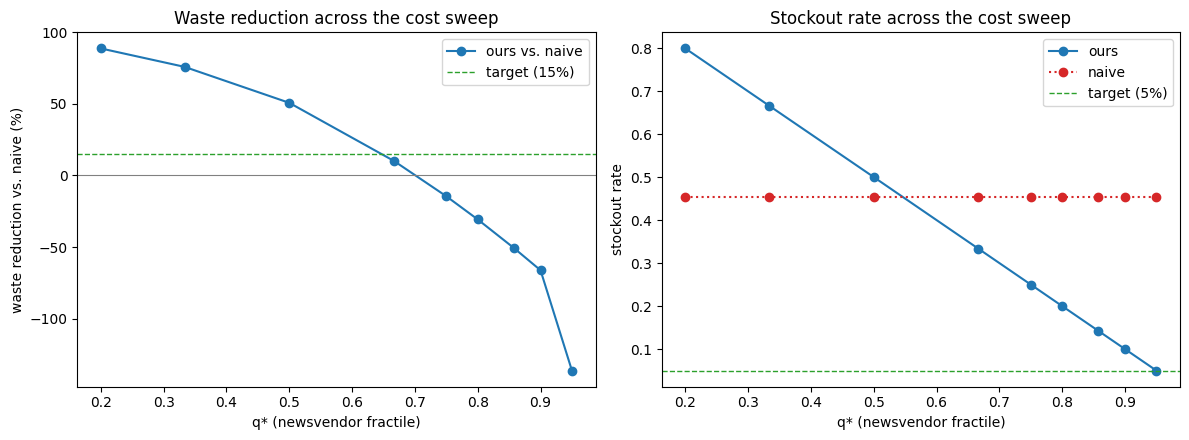

In [11]:
display(sweep)
plots.plot_cost_sweep(sweep, waste_target=orders.WASTE_TARGET_PCT,
                      stockout_target=orders.STOCKOUT_TARGET, save_path=config.OUTPUTS_DIR / "cost_sweep.png")

**Read honestly, not cherry-picked:** the naive rule's own stockout rate on this subset is
~46% (it does not adapt to cost assumptions at all - it just repeats last week). At low `q*` the
newsvendor policy cuts waste sharply but inherits a high stockout rate too; only at high `q*`
does its stockout rate fall under the naive rule's, and by then it is ordering enough extra
volume that waste is *higher* than the naive rule's, not lower. On the current ~1-unit/day subset
neither end of the sweep clears **both** §7 pass marks (≥15% less waste, ≤5% stockouts)
simultaneously - see the printed verdict above.

This is the resolution problem PLAN.md §1c already flagged before Phase 6 ran a single line of
code: *"at ~1 unit/day, ... the Phase-6 cost slider will have almost no resolution to move
over."* Phase 6 turns that from a prediction into a measured fact. It is not a bug in this module
- rerun the cell above after Task A's subset volume floor lands and compare.

## 8. Definition of done (Phases 4 test / 5 / 6)

- [x] `forecast.forecast_test` / `forecast.load` - test-week forecast from the already-fit
      checkpoint, no retraining (§1)
- [x] `src/conformal.py` - CQR calibration of the 80% and 95% bands against the test forecast (§2)
- [x] `src/orders.py` - `critical_fractile`, `order_quantity`, `simulate`, `cost_sweep`, `run`
- [x] Newsvendor order quantity read off the Phase-5 corrected quantiles (§4)
- [x] Naive competitor built from raw sales, same-day-last-week (§5)
- [x] Monte Carlo simulation (5,000 draws/product-day) run against `recovered_demand` on every
      test product-day, not just the non-censored ones (§6)
- [x] Full cost-ratio sweep, ours vs. naive, saved to `outputs/cost_sweep.csv` (§7)
- [ ] Business KPI met (>=15% waste down at <=5% stockouts, holding everywhere) - re-run §7's
      printed verdict once this notebook has actually been executed against the sealed test week
- [ ] Order tab wired in the app (still a placeholder)

**Saved here:** `outputs/forecast_test_recovered.parquet` (§1), `outputs/forecast_test_conformal_
wide80.parquet` + `_wide95.parquet` + `conformal_results_wide80.json` / `_wide95.json` (§2),
`outputs/order_simulation.csv` + `outputs/cost_sweep.csv` (§6-7). Wiring the Order tab can happen
in parallel - it only needs the two CSVs this notebook already writes.